# 🎮 Video Game Sales Prediction

## Business Problem

Video game publishers invest millions in developing and marketing new games. Estimating global sales before release can support decisions related to budgeting, marketing, and production.

The goal of this project is to build a machine learning regression model capable of predicting a game's global sales based on its characteristics.

---

## Objectives

- Understand the dataset
- Prepare the data for machine learning
- Train a Linear Regression model
- Evaluate its performance
- Interpret the results
- Save the trained model
- Deploy a prediction application using Streamlit

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import plotly.express as px

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Save models
import joblib


In [2]:
df = pd.read_csv("../data/video_games.csv")

In [3]:
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.shape

(16719, 16)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  str    
 1   Platform         16719 non-null  str    
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  str    
 4   Publisher        16665 non-null  str    
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  str    
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  str    
 15  Rating           9950 non-null   str    
dtypes: float64(9), str(7)
memory usage: 3.0 MB


In [6]:
df.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,16450.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,8137.000000,8137.000000,7590.000000
mean,2006.487356,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,26.360821,162.229908
std,5.878995,0.813514,0.503283,0.308818,0.186710,1.547935,13.938165,18.980495,561.282326
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,10.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.000000,81.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,10665.000000


In [7]:
df.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating'],
      dtype='str')

## Investigating User Score

In [10]:
df["User_Score"].unique()

<ArrowStringArray>
[  '8',   nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4', '8.2',
   '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2', '8.9', '6.4',
 '7.8', '7.5', '2.6', '7.2', '9.2',   '7', '7.3', '4.3', '7.6', '5.7',   '5',
 '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8', '6.1', '6.7', '5.4',   '4',
 '4.9', '4.5', '9.3', '6.2', '4.2',   '6', '3.7', '4.1', '5.8', '5.6', '5.5',
 '4.4', '4.6', '5.9', '3.9', '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5',
 '2.5', '1.9',   '3', '2.7', '2.2',   '2', '9.5', '2.1', '3.6', '2.8', '1.8',
 '3.8',   '0', '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
 '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9',   '1', '9.7']
Length: 97, dtype: str

In [ ]:
df["User_Score"].value_counts(dropna=False)

User_Score
NaN    6704
tbd    2425
7.8     324
8       290
8.2     282
       ... 
0.6       2
0.9       2
1         2
0         1
9.7       1
Name: count, Length: 97, dtype: int64

: 

### Cleaning

In [11]:
df["User_Score"] = df["User_Score"].replace("tbd", np.nan)

In [12]:
df["User_Score"] = pd.to_numeric(df["User_Score"])

In [13]:
df["User_Score"].dtype

dtype('float64')

In [14]:
df["User_Score"].describe()

count    7590.000000
mean        7.125046
std         1.500006
min         0.000000
25%         6.400000
50%         7.500000
75%         8.200000
max         9.700000
Name: User_Score, dtype: float64

## Feature Selection

In [15]:
X = df.drop(columns=[
    "Global_Sales",
    "Name",
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales"
])

y = df["Global_Sales"]

In [16]:
X.head()

,Platform,Year_of_Release,Genre,Publisher,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii,2006.0,Sports,Nintendo,76.0,51.0,8.0,322.0,Nintendo,E
1,NES,1985.0,Platform,Nintendo,NaN,NaN,NaN,NaN,NaN,NaN
2,Wii,2008.0,Racing,Nintendo,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii,2009.0,Sports,Nintendo,80.0,73.0,8.0,192.0,Nintendo,E
4,GB,1996.0,Role-Playing,Nintendo,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
X.shape

(16719, 10)

In [18]:
y.head()

0    82.53
1    40.24
2    35.52
3    32.77
4    31.37
Name: Global_Sales, dtype: float64

In [19]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Platform         16719 non-null  str    
 1   Year_of_Release  16450 non-null  float64
 2   Genre            16717 non-null  str    
 3   Publisher        16665 non-null  str    
 4   Critic_Score     8137 non-null   float64
 5   Critic_Count     8137 non-null   float64
 6   User_Score       7590 non-null   float64
 7   User_Count       7590 non-null   float64
 8   Developer        10096 non-null  str    
 9   Rating           9950 non-null   str    
dtypes: float64(5), str(5)
memory usage: 1.8 MB


In [20]:
X.head()

,Platform,Year_of_Release,Genre,Publisher,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii,2006.0,Sports,Nintendo,76.0,51.0,8.0,322.0,Nintendo,E
1,NES,1985.0,Platform,Nintendo,NaN,NaN,NaN,NaN,NaN,NaN
2,Wii,2008.0,Racing,Nintendo,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii,2009.0,Sports,Nintendo,80.0,73.0,8.0,192.0,Nintendo,E
4,GB,1996.0,Role-Playing,Nintendo,NaN,NaN,NaN,NaN,NaN,NaN


## Data Preprocessing Pipeline

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [22]:
numeric_features = [
    "Year_of_Release",
    "Critic_Score",
    "Critic_Count",
    "User_Score",
    "User_Count"
]

categorical_features = [
    "Platform",
    "Genre",
    "Publisher",
    "Developer",
    "Rating"
]

In [23]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

In [24]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Train-Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [27]:
print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)

print("Training labels  :", y_train.shape)
print("Testing labels   :", y_test.shape)

Training features: (13375, 10)
Testing features : (3344, 10)
Training labels  : (13375,)
Testing labels   : (3344,)


## Model Training

In [28]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

In [29]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Platform','Year_of_Release','Genre',...,'User_Count','Developer', 'Rating']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset 

In [30]:
y_pred = model.predict(X_test)

In [31]:
predictions = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

predictions.head(10)

,Actual,Predicted
6991,0.23,0.421374
16195,0.01,0.025199
9862,0.12,-0.066946
11152,0.09,0.800997
8642,0.16,0.341661
14180,0.03,-0.037840
12300,0.06,0.772816
12710,0.06,-0.076232
8998,0.14,0.293492
5862,0.30,-0.012450


## Model Evaluation

In [32]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MAE : 0.5342
MSE : 3.3256
RMSE: 1.8236
R²  : 0.1944


## Actual vs Predicted Values

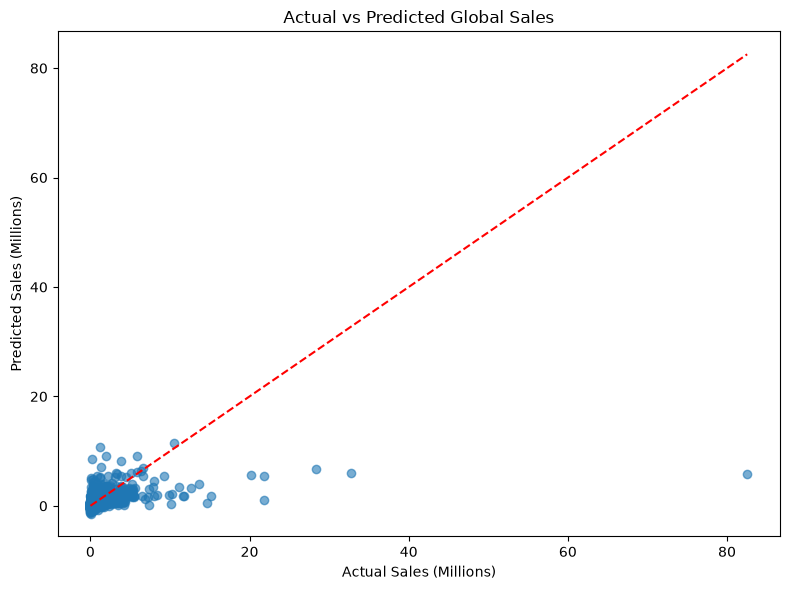

In [33]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.title("Actual vs Predicted Global Sales")
plt.xlabel("Actual Sales (Millions)")
plt.ylabel("Predicted Sales (Millions)")

plt.tight_layout()

plt.savefig("../screenshots/actual_vs_predicted.png", dpi=300)

plt.show()

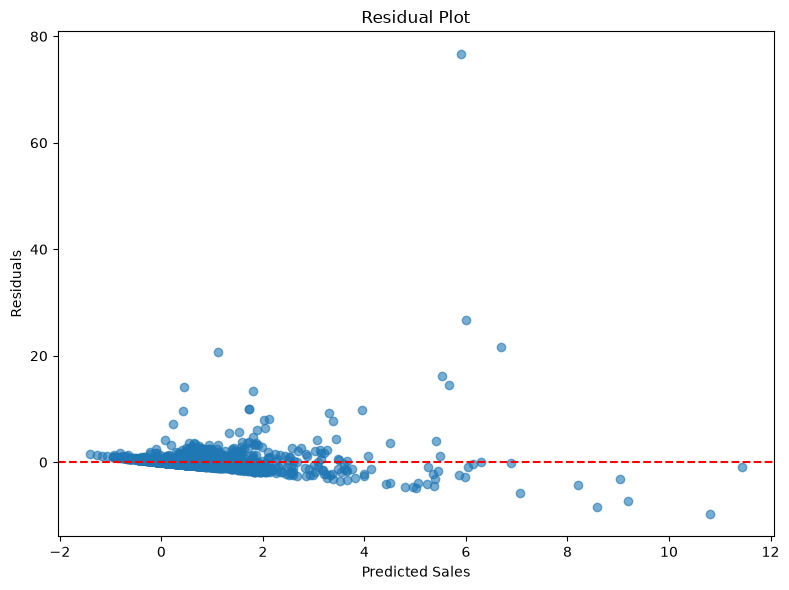

In [34]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(0, color="red", linestyle="--")

plt.title("Residual Plot")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.tight_layout()

plt.savefig("../screenshots/residual_plot.png", dpi=300)

plt.show()

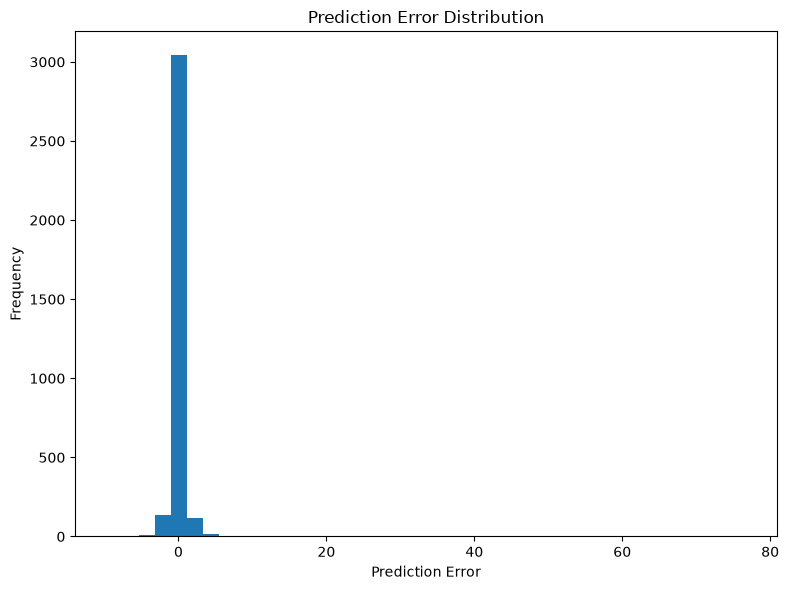

In [35]:
errors = y_test - y_pred

plt.figure(figsize=(8,6))

plt.hist(errors, bins=40)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("../screenshots/error_distribution.png", dpi=300)

plt.show()

## Improving the model

In [36]:
from sklearn.ensemble import RandomForestRegressor

In [37]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=100,
            random_state=42
        ))
    ]
)

In [38]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Platform','Year_of_Release','Genre',...,'User_Count','Developer', 'Rating']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset 

In [39]:
rf_pred = rf_model.predict(X_test)

In [40]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print(f"MAE : {rf_mae:.4f}")
print(f"MSE : {rf_mse:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"R²  : {rf_r2:.4f}")

MAE : 0.3837
MSE : 2.6712
RMSE: 1.6344
R²  : 0.3529


In [41]:
comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Linear Regression": [
        mae,
        rmse,
        r2
    ],
    "Random Forest": [
        rf_mae,
        rf_rmse,
        rf_r2
    ]
})

comparison

,Metric,Linear Regression,Random Forest
0,MAE,0.534245,0.383721
1,RMSE,1.823624,1.634367
2,R²,0.194370,0.352910


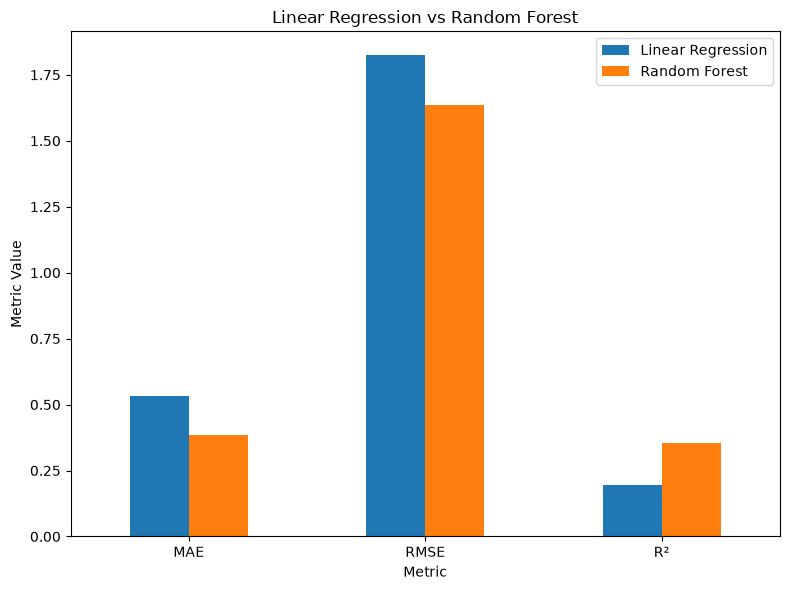

In [42]:
comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(8, 6)
)

plt.title("Linear Regression vs Random Forest")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("../screenshots/model_comparison.png", dpi=300)

plt.show()

## Model Explainability

In [43]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

In [44]:
importances = rf_model.named_steps["regressor"].feature_importances_

In [45]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
0,num__Year_of_Release,0.172537
4,num__User_Count,0.155344
389,cat__Publisher_Nintendo,0.069567
1,num__Critic_Score,0.057402
18,cat__Platform_PC,0.042616
2,num__Critic_Count,0.041327
1534,cat__Developer_Nintendo,0.030360
43,cat__Genre_Role-Playing,0.029689
1722,cat__Developer_Rockstar North,0.029356
3,num__User_Score,0.026083


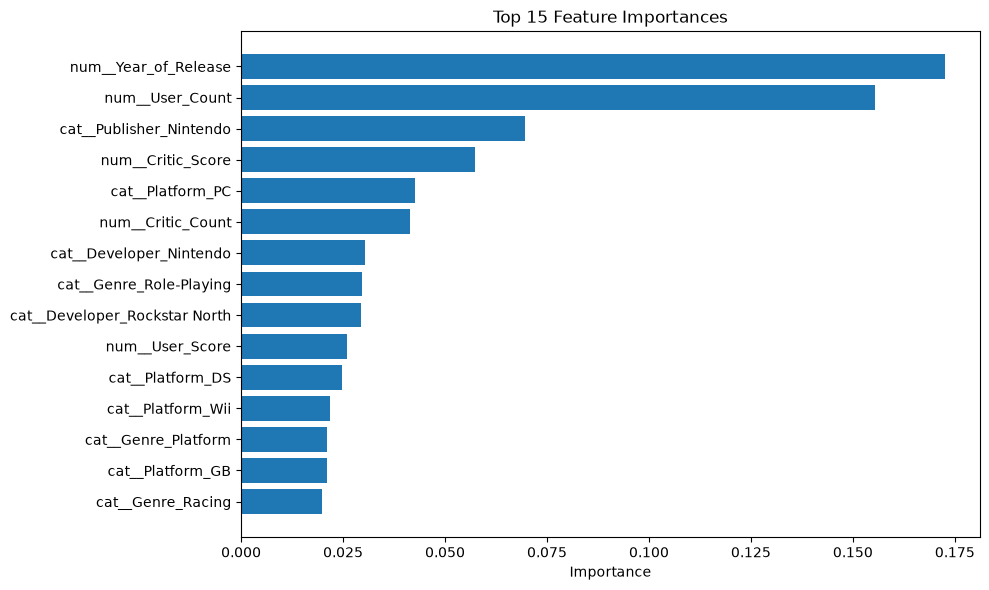

In [46]:
top_features = importance_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("../screenshots/feature_importance.png", dpi=300)

plt.show()

## Model Persistence

In [47]:
joblib.dump(
    rf_model,
    "../models/video_game_sales_rf.pkl"
)

['../models/video_game_sales_rf.pkl']

In [ ]:
#Load
loaded_model = joblib.load(
    "../models/video_game_sales_rf.pkl"
)